# Graph
The graph is collected and stored as:
- json: data/flights_week_graph_with_nut3.json
- 3 csv im data/graph_csv

It is easier to open from json file, operate on domain Graph model and use adapters to convert to other models/formats. For example, you can convert to pandas data frame with GraphPandasAdapter

In [1]:
from graph_creation.adapters.input import GraphJsonLoader
gr = GraphJsonLoader().load("./data/flights_week_graph_with_nut3.json")
gr

Graph(nodes_number=513, edges_number=10236, unknown_or_non_eu_dep=430734, unknown_or_non_eu_arr=15106, countries=['AT', 'BE', 'BG', 'CH', 'CY', 'CZ', 'DE', 'DK', 'EE', 'ES', 'FI', 'FR', 'GB', 'GR', 'HR', 'HU', 'IE', 'IT', 'LT', 'LU', 'LV', 'MT', 'NL', 'NO', 'PL', 'PT', 'RO', 'SE', 'SI', 'SK', 'TR'], begin=2026-02-16 00:00:00 UTC, end=2026-02-22 23:59:59 UTC)

In [2]:
from graph_creation.adapters.output.graph import GraphPandasAdapter
pa = GraphPandasAdapter(gr)

In [3]:
nodes_df = pa.nodes_to_df()
nodes_df.head()

,id,name,iso_country,iso_region,latitude,longitude,airports_count,out_flights_number,in_flights_number,nut3_code
0,"Mehamn, NO",Mehamn,NO,NO-56,71.029701,27.826700,1,3,0,NO0B2
1,"Antalya, TR",Antalya,TR,TR-07,36.898701,30.800501,1,447,289,TR611
2,"Charlestown, IE",Charlestown,IE,IE-MO,53.910439,-8.817002,1,48,49,IE042
3,"Béziers, FR",Béziers,FR,FR-OCC,43.323502,3.353900,1,1,2,FRJ13
4,"Nîmes/Garons, FR",Nîmes/Garons,FR,FR-OCC,43.757401,4.416350,1,19,21,FRJ12


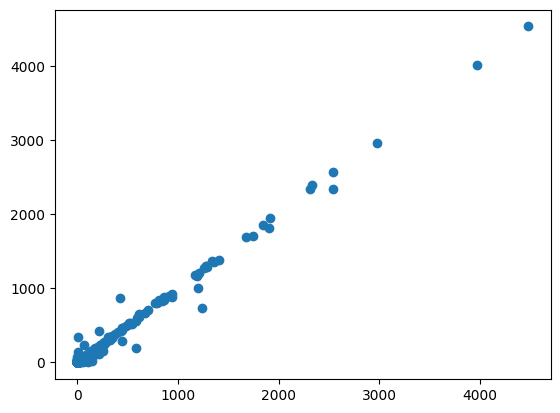

In [4]:
import matplotlib.pyplot as plt
plt.scatter(nodes_df['out_flights_number'], nodes_df['in_flights_number'])
plt.show()

In [5]:
edges_df = pa.edges_to_df()
edges_df.head()

,from_id,to_id,weight,distance
0,"Aalborg, DK","Billund, DK",2,156.52
1,"Aalborg, DK","Oslo (Gardermoen), NO",6,352.11
2,"Aalborg, DK","Copenhagen, DK",84,238.40
3,"Aalborg, DK","Amsterdam, NL",28,624.13
4,"Aalborg, DK","Málaga, ES",3,2507.05


## Embedings

In [6]:
import json 
with open("./data/embedings_from_callsign.json") as f:
    callsign_dct = json.load(f)

with open("./data/embedings_from_icao.json") as f:
    icao_dct = json.load(f)

with open("./data/icao_to_model.json") as f:
    icao_to_model = json.load(f)

from graph_creation.domain.graph import Embedding
callsign_embedings_lst: list[Embedding] = []
icao_embedings_lst: list[Embedding] = []

for group in callsign_dct['groups']:
    callsign_embedings_lst.append(Embedding(
        name=group['label'],
        matching_columns=group['codes']
    ))
for group in icao_dct['groups']:
    icao_embedings_lst.append(Embedding(
        name=group['label'],
        matching_columns=group['model_contains']
    ))

In [7]:
matrix = gr.create_edge_embeddings(callsign_embedings_lst, icao_embedings_lst, icao_to_model, assign_to_edges=True)

import pandas as pd
df = pd.DataFrame(matrix, columns=gr.edge_embedding_columns)
df.shape

(10236, 51)

In [8]:
# TODO filter nodes/edges, leave only important = with the data
df.head()

,Lufthansa Group (passenger),Air France–KLM Group,IAG (Iberia/Vueling/Aer Lingus),Turkish Airlines (hub carrier),Nordics / North Atlantic flag carriers,Southern Europe flag carriers,Swiss regionals / leisure (non-Lufthansa-group),Central/Eastern Europe & Benelux flag carriers,Ryanair Group,easyJet (all AOCs),...,Airbus A330 family (incl. freighter/P2F strings),Airbus A350 family,Other Airbus widebodies (A300/A310/A340/A380),Boeing 777 family (incl. freighter),Boeing 787 family (Dreamliner),Boeing 767 family (incl. cargo conversions),Boeing 757 family (incl. SF/PCF),Boeing 747 family (incl. 747-8F),Eastern heavy cargo (An-124 etc.),Unknown / missing / not matched
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,4,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,41,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,28,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [9]:
df.sum().sort_values(ascending=False)

Airbus A318/A319/A320/A321 (+neo)                                                   20512
Ryanair Group                                                                       12185
Lufthansa Group (passenger)                                                          9106
IAG (Iberia/Vueling/Aer Lingus)                                                      8076
Air France–KLM Group                                                                 8002
easyJet (all AOCs)                                                                   7435
Boeing 737 (Classic/NG family; non-MAX)                                              6436
Boeing 737 MAX (8/9/7, incl. MAX-200)                                                5693
Nordics / North Atlantic flag carriers                                               5653
Other major EU LCC / leisure-LCC                                                     3384
Southern Europe flag carriers                                                        3225
Turkish Ai